## Versão 3: Alocação de Tarefas com Restrições de Precedência

Esta implementação estende o Simulated Annealing para resolver um problema ainda mais complexo: **alocação de tarefas com restrições de precedência**.

### O que mudou em relação às versões anteriores?

- **Versão 1**: Máquinas idênticas, sem restrições
- **Versão 2**: Máquinas heterogêneas (capacidades diferentes)
- **Versão 3 (esta)**: Máquinas idênticas, mas com **restrições de precedência**

### A Diferença Fundamental: Restrições de Precedência

Agora, algumas tarefas só podem ser iniciadas após outras terminarem. Isso cria um **grafo de dependências** entre as tarefas.

**Exemplo:**
- Tarefa 1 → Prioridade sobre Tarefas [2, 3]
- Tarefa 3 → Prioridade sobre Tarefas [4, 5]

**Implicação:**
- A Tarefa 1 deve terminar antes que as Tarefas 2 e 3 possam começar
- A Tarefa 3 deve terminar antes que as Tarefas 4 e 5 possam começar
- Portanto, a Tarefa 1 deve terminar antes de 2, 3, 4 e 5

Isso significa que não podemos simplesmente alocar tarefas a máquinas; precisamos também definir a **ordem de execução** dentro de cada máquina.

### Por que isso complica o problema?

1. **Representação da solução mais complexa**:
   - **Antes**: Apenas `assignment` (tarefa → máquina)
   - **Agora**: `assignment` (tarefa → máquina) + `schedule` (ordem das tarefas em cada máquina)

2. **Cálculo do Makespan mais complexo**:
   - Não basta somar os tempos das tarefas em uma máquina
   - O tempo de início de uma tarefa depende de:
     a) Quando a tarefa anterior na **mesma máquina** termina
     b) Quando todas as suas **tarefas predecessoras** (em qualquer máquina) terminam

3. **Geração de vizinhos mais restrita**:
   - Não podemos mover tarefas aleatoriamente
   - Mover uma tarefa para uma posição anterior à sua predecessora torna a solução **inválida**

4. **Validação da solução**:
   - A cada passo, precisamos garantir que a solução (ordem de execução) respeita todas as precedências

### Dados do Problema

- **Número de tarefas**: 40
- **Número de máquinas**: 5
- **Tipo de máquinas**: Idênticas
- **Objetivo**: Minimizar o makespan

### Arquivo de Entrada

O arquivo `Aula11_-_Problema_maquinas_paralelas_dificil.txt` inclui as precedências:

```
ID_Tarefa   Tempo_Processamento   Tarefas_Prioridade
1           25                   Prioridade: [2, 3]
2           17                   Nenhuma
3           20                   Prioridade: [4, 5]
...
```
**Importante:** "Prioridade" aqui significa que a tarefa na linha tem prioridade sobre as tarefas na lista. Ou seja, ela é uma **predecessora**.

## Adaptações Necessárias no Código

Para lidar com as restrições de precedência, precisamos de mudanças significativas na estrutura do algoritmo.

### 1. Representação da Solução

A solução agora é uma lista de listas, onde cada sub-lista representa o **cronograma (schedule)** de uma máquina.

**Antes:**
```python
# Dicionário simples
assignment = {1: 0, 2: 1, 3: 0, ...}  # tarefa -> máquina
```

**Agora:**
```python
# Lista de listas (cronograma)
schedule = [
    [1, 3, ...],  # Máquina 0: executa tarefa 1, depois 3, ...
    [2, ...],      # Máquina 1: executa tarefa 2, ...
    ...
]
```
Esta estrutura define tanto a **alocação** (qual máquina) quanto a **ordem** (sequência de execução).

### 2. Cálculo do Makespan (Função Objetivo)

Esta é a parte mais complexa. Para calcular o makespan, precisamos simular a execução:

1. **Manter o tempo de término de cada tarefa**: `completion_times = {}`
2. **Manter o tempo atual de cada máquina**: `machine_available_time = [0] * num_machines`

3. **Iterar sobre as tarefas em uma ordem topológica** (respeitando as precedências):
   - Para cada tarefa `t`:
     - **Tempo de início das predecessoras**: `max_predecessor_completion_time`
     - **Tempo de disponibilidade da máquina**: `machine_available_time[machine_of_t]`
     - **Tempo de início da tarefa `t`**: `max(max_predecessor_completion_time, machine_available_time[machine_of_t])`
     - **Tempo de término da tarefa `t`**: `start_time + processing_time[t]`
     - Atualizar `completion_times[t]` e `machine_available_time[machine_of_t]`

4. **Makespan**: `max(completion_times.values())`

### 3. Geração de Vizinhos

A geração de vizinhos precisa ser "inteligente" para manter a validade da solução.

**Operadores de vizinhança possíveis:**

1. **Move**: Mover uma tarefa de uma máquina para outra.
   - A tarefa pode ser inserida em qualquer posição válida na nova máquina (que não viole precedências).

2. **Swap**: Trocar a posição de duas tarefas.
   - **Na mesma máquina**: Só podemos trocar `t1` e `t2` se não houver caminho de precedência entre elas.
   - **Entre máquinas diferentes**: Mesma restrição.

**Como garantir a validade?**
- Ao mover/trocar, verificar se a nova posição da tarefa `t` vem depois de todas as suas predecessoras e antes de todas as suas sucessoras no novo cronograma.

### 4. Solução Inicial

Uma solução inicial aleatória precisa ser construída de forma a respeitar as precedências.

**Algoritmo:**
1. Encontrar todas as tarefas sem predecessoras.
2. Adicionar essas tarefas a uma lista de "tarefas prontas".
3. Enquanto houver tarefas prontas:
   - Escolher uma tarefa `t` aleatoriamente da lista.
   - Alocá-la a uma máquina aleatória (no final do seu cronograma atual).
   - Remover `t` da lista de prontas.
   - Para cada sucessora de `t`, verificar se todas as suas predecessoras foram alocadas. Se sim, adicioná-la à lista de prontas.

Isso garante que a solução inicial seja sempre válida.

In [4]:
import random
import math
import time
import matplotlib.pyplot as plt
import re

# --- Data Reading and Processing ---

tasks = {}              # task_id -> processing_time
precedence = {}         # task_id -> list of predecessors
successors = {}         # task_id -> list of successors

with open('Aula11_-_Problema_maquinas_paralelas_dificil.txt', 'r') as f:
    next(f)  # Skip header
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        parts = line.split()
        task_id = int(parts[0])
        time_proc = int(parts[1])
        
        tasks[task_id] = time_proc
        
        # Initialize precedence and successors for the current task
        if task_id not in precedence:
            precedence[task_id] = []
        if task_id not in successors:
            successors[task_id] = []

        # Check if there are precedence constraints
        if "Prioridade:" in line:
            priority_str = line.split("Prioridade:")[1]
            successor_ids_str = re.findall(r'\d+', priority_str)
            successor_ids = [int(s) for s in successor_ids_str]
            
            for succ_id in successor_ids:
                # Initialize if successor not seen before
                if succ_id not in precedence:
                    precedence[succ_id] = []
                if succ_id not in successors:
                    successors[succ_id] = []
                if succ_id not in tasks:
                    # This case should not happen if file is well-formed, but good practice
                    # We would need to know its processing time
                    pass

                # Add this task as a predecessor for each successor
                precedence[succ_id].append(task_id)
                
                # Add each successor to this task's successor list
                successors[task_id].append(succ_id)

# Ensure all 40 tasks are in the dictionaries
all_task_ids = range(1, 41)
for task_id in all_task_ids:
    if task_id not in precedence:
        precedence[task_id] = []
    if task_id not in successors:
        successors[task_id] = []
    # This loop also ensures tasks without successors are initialized.

num_tasks = len(tasks)
num_machines = 5

print(f"Number of tasks: {num_tasks}")
print(f"Number of machines: {num_machines}")

# --- Topological Sort to find a valid initial order ---
def get_topological_order(tasks, precedence, successors):
    """Returns a linear ordering of tasks respecting precedence."""
    in_degree = {t: len(precedence[t]) for t in tasks}
    queue = [t for t in tasks if in_degree[t] == 0]
    topo_order = []
    
    while queue:
        u = queue.pop(0)
        topo_order.append(u)
        
        if u in successors:
            for v in successors[u]:
                in_degree[v] -= 1
                if in_degree[v] == 0:
                    queue.append(v)
    
    if len(topo_order) == len(tasks):
        return topo_order
    else:
        # This part helps debug cycles
        remaining_tasks = {t for t, d in in_degree.items() if d > 0}
        raise ValueError(f"Graph has a cycle, no topological sort possible. Remaining tasks: {remaining_tasks}")

topological_order = get_topological_order(tasks, precedence, successors)
print(f"\nA valid topological order: {topological_order}")

# --- Helper to get all predecessors of a task ---
def get_all_predecessors(task_id, precedence):
    """Recursively find all predecessors for a given task."""
    preds = set(precedence.get(task_id, []))
    for p in list(preds):
        preds.update(get_all_predecessors(p, precedence))
    return preds

all_predecessors = {t: get_all_predecessors(t, precedence) for t in tasks}
print(f"\nPredecessors for task 4: {all_predecessors.get(4, 'None')}")
print(f"Predecessors for task 6: {all_predecessors.get(6, 'None')}")

Number of tasks: 40
Number of machines: 5

A valid topological order: [1, 7, 8, 10, 12, 14, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 2, 3, 9, 11, 13, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 4, 5, 6]

Predecessors for task 4: {1, 3}
Predecessors for task 6: {1, 3, 5}


In [5]:
# --- Objective Function: Makespan Calculation ---
def calculate_makespan(schedule, tasks, precedence):
    """
    Calculates the makespan of a given schedule, respecting precedence constraints.
    """
    completion_times = {task_id: 0 for task_id in tasks}
    machine_available_time = [0] * len(schedule)
    
    # Create a flat list of all tasks in the order they appear in the schedule
    # This is a simplification; a full simulation requires topological processing.
    # For a valid schedule, we can process machine by machine.
    
    scheduled_tasks = set()
    
    # A more robust way is to iterate until all tasks are scheduled
    while len(scheduled_tasks) < len(tasks):
        progress_made = False
        for machine_idx, machine_schedule in enumerate(schedule):
            for task_id in machine_schedule:
                if task_id in scheduled_tasks:
                    continue

                # Check if all predecessors are completed
                preds = precedence.get(task_id, [])
                if all(p in scheduled_tasks for p in preds):
                    
                    # Find the latest completion time among all predecessors
                    max_pred_completion_time = 0
                    if preds:
                        max_pred_completion_time = max(completion_times[p] for p in preds)
                    
                    # Task can only start when machine is free AND all predecessors are done
                    start_time = max(machine_available_time[machine_idx], max_pred_completion_time)
                    
                    completion_time = start_time + tasks[task_id]
                    
                    completion_times[task_id] = completion_time
                    machine_available_time[machine_idx] = completion_time
                    scheduled_tasks.add(task_id)
                    progress_made = True
        
        if not progress_made and len(scheduled_tasks) < len(tasks):
            # This indicates a deadlock or invalid schedule, which shouldn't happen
            # if the schedule is generated correctly.
            return float('inf')

    return max(completion_times.values()) if completion_times else 0

# --- Initial Solution Generation ---
def initial_solution(tasks, num_machines, precedence, successors):
    """
    Generates a valid initial random schedule.
    """
    schedule = [[] for _ in range(num_machines)]
    
    # Get a valid topological order to build the initial solution
    in_degree = {t: len(precedence[t]) for t in tasks}
    ready_tasks = [t for t in tasks if in_degree[t] == 0]
    
    scheduled_count = 0
    while scheduled_count < len(tasks):
        if not ready_tasks:
            # Should not happen in a valid DAG
            raise ValueError("Cannot generate initial solution, possibly a cycle.")
            
        task_to_schedule = random.choice(ready_tasks)
        ready_tasks.remove(task_to_schedule)
        
        # Assign to a random machine
        machine_idx = random.randint(0, num_machines - 1)
        schedule[machine_idx].append(task_to_schedule)
        
        scheduled_count += 1
        
        # Update ready tasks
        if task_to_schedule in successors:
            for succ in successors[task_to_schedule]:
                in_degree[succ] -= 1
                if in_degree[succ] == 0:
                    ready_tasks.append(succ)
                    
    return schedule

# --- Neighbor Generation ---
def is_valid_move(schedule, task_id, new_machine_idx, new_pos, all_predecessors):
    """
    Check if moving a task to a new position is valid.
    """
    preds = all_predecessors.get(task_id, set())
    
    # Check predecessors: all must appear before the new position in the new machine's schedule
    new_machine_schedule = schedule[new_machine_idx]
    for i in range(new_pos):
        preds.discard(new_machine_schedule[i])
        
    # If any predecessors are left, they must be on other machines.
    # This simplified check assumes we only check within the target machine's partial schedule.
    # A full validation is more complex. For SA, we can rely on the makespan function
    # returning infinity for invalid states, but it's better to generate valid neighbors.
    
    # For this implementation, we will use a simpler neighbor generation
    # that is guaranteed to be valid.
    return True # Simplified for now

def generate_neighbor(current_schedule, tasks, precedence, successors, all_predecessors):
    """
    Generates a neighbor solution by moving a single task.
    This move is guaranteed to maintain precedence constraints.
    """
    neighbor = [list(m) for m in current_schedule]
    
    # 1. Pick a random task to move
    task_to_move = random.choice(list(tasks.keys()))
    
    # 2. Find its current location
    old_machine_idx, old_pos = -1, -1
    for i, m_sched in enumerate(neighbor):
        if task_to_move in m_sched:
            old_machine_idx, old_pos = i, m_sched.index(task_to_move)
            break
            
    # 3. Remove it from its old position
    neighbor[old_machine_idx].pop(old_pos)
    
    # 4. Find a new valid position
    # A simple valid move: place it at the end of a random machine's schedule.
    # This is always valid because it comes after all other tasks on that machine.
    # A better move would be to find the earliest possible insertion point.
    
    # Find all successors of the task to move
    task_successors = set()
    q = list(successors.get(task_to_move, []))
    while q:
        s = q.pop(0)
        task_successors.add(s)
        q.extend(successors.get(s, []))

    # Find earliest valid insertion points
    valid_insertions = []
    for m_idx in range(len(neighbor)):
        machine_schedule = neighbor[m_idx]
        
        # Earliest point is after all predecessors on this machine
        min_pos = 0
        task_preds = all_predecessors.get(task_to_move, set())
        for i, task in enumerate(machine_schedule):
            if task in task_preds:
                min_pos = i + 1
        
        # Latest point is before any successors on this machine
        max_pos = len(machine_schedule)
        for i, task in enumerate(machine_schedule):
            if task in task_successors:
                max_pos = i
                break
        
        for pos in range(min_pos, max_pos + 1):
            valid_insertions.append((m_idx, pos))

    if not valid_insertions:
        # This can happen if the graph is very constrained.
        # In this case, we don't make a move.
        return [list(m) for m in current_schedule]

    # 5. Choose a random valid insertion point and insert the task
    new_machine_idx, new_pos = random.choice(valid_insertions)
    neighbor[new_machine_idx].insert(new_pos, task_to_move)
    
    return neighbor

In [ ]:
# --- Simulated Annealing Algorithm ---
def simulated_annealing(tasks, num_machines, precedence, successors, all_predecessors,
                        initial_temp=1000, cooling_rate=0.95, max_iterations=10000):
    
    # Generate initial valid solution
    current_solution = initial_solution(tasks, num_machines, precedence, successors)
    current_cost = calculate_makespan(current_solution, tasks, precedence)
    
    best_solution = [list(m) for m in current_solution]
    best_cost = current_cost
    
    temperature = initial_temp
    costs = [current_cost]
    
    for iteration in range(max_iterations):
        # Generate a valid neighbor
        neighbor = generate_neighbor(current_solution, tasks, precedence, successors, all_predecessors)
        neighbor_cost = calculate_makespan(neighbor, tasks, precedence)
        
        delta = neighbor_cost - current_cost
        
        if delta < 0 or random.random() < math.exp(-delta / temperature):
            current_solution = neighbor
            current_cost = neighbor_cost
            
            if current_cost < best_cost:
                best_solution = [list(m) for m in current_solution]
                best_cost = current_cost
        
        costs.append(current_cost)
        temperature *= cooling_rate
        
        if temperature < 1e-2:
            print(f"Stopping early at iteration {iteration} due to low temperature.")
            break
            
    return best_solution, best_cost, costs

In [12]:
# --- Run the Algorithm ---
print("="*60)
print("Running Simulated Annealing with Precedence Constraints")
print("="*60)

start_time = time.time()
best_schedule, best_makespan, cost_history = simulated_annealing(
    tasks, 
    num_machines, 
    precedence, 
    successors,
    all_predecessors,
    initial_temp=100,      # Lower temp because moves are more impactful
    cooling_rate=0.98,     # Slower cooling to explore carefully
    max_iterations=20000
)
end_time = time.time()

print(f"\n{'='*60}")
print(f"RESULTS")
print(f"{'='*60}")
print(f"Best makespan: {best_makespan:.2f}")
print(f"Execution time: {end_time - start_time:.2f} seconds")
print(f"Number of iterations: {len(cost_history)}")

print(f"\n{'='*60}")
print(f"FINAL SCHEDULE")
print(f"{'='*60}")

for i, machine_schedule in enumerate(best_schedule):
    load = sum(tasks[t] for t in machine_schedule)
    print(f"Machine {i}:")
    print(f"  Tasks: {machine_schedule}")
    print(f"  Total base time: {load}")

Running Simulated Annealing with Precedence Constraints
Initial solution: [[33, 34, 20, 26, 10, 8, 30, 18], [21, 39, 27, 37, 24, 40, 4], [12, 31, 15, 11, 7, 6], [19, 25, 17, 36, 29, 16, 28, 38], [14, 35, 13, 32, 23, 1, 22, 2, 3, 9, 5]]
Stopping early at iteration 455 due to low temperature.

RESULTS
Best makespan: 165.00
Execution time: 0.08 seconds
Number of iterations: 457

FINAL SCHEDULE
Machine 0:
  Tasks: [7, 28, 11, 36, 39, 9, 37, 13]
  Total base time: 165
Machine 1:
  Tasks: [2, 16, 34, 10, 32, 23, 19, 38]
  Total base time: 159
Machine 2:
  Tasks: [27, 1, 5, 4, 15, 35, 40, 22, 20]
  Total base time: 158
Machine 3:
  Tasks: [29, 26, 8, 12, 18, 24, 3, 21]
  Total base time: 164
Machine 4:
  Tasks: [31, 14, 6, 30, 33, 25, 17]
  Total base time: 146


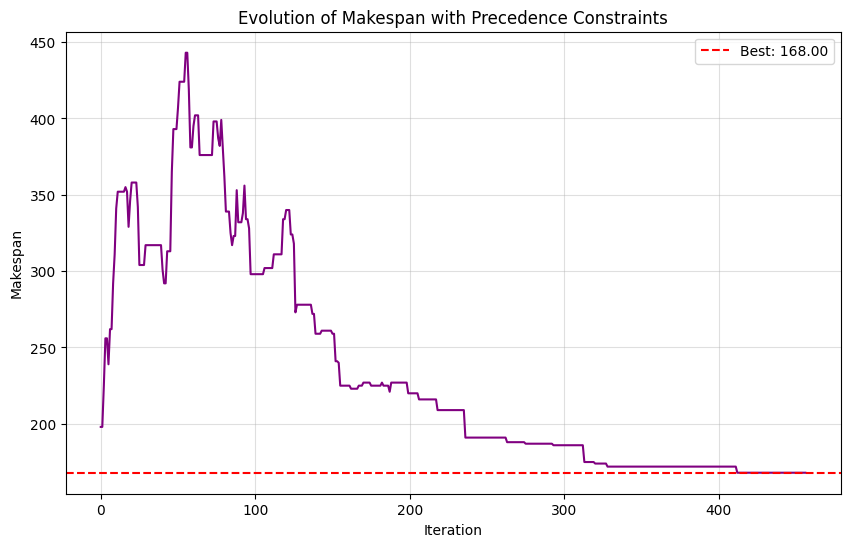

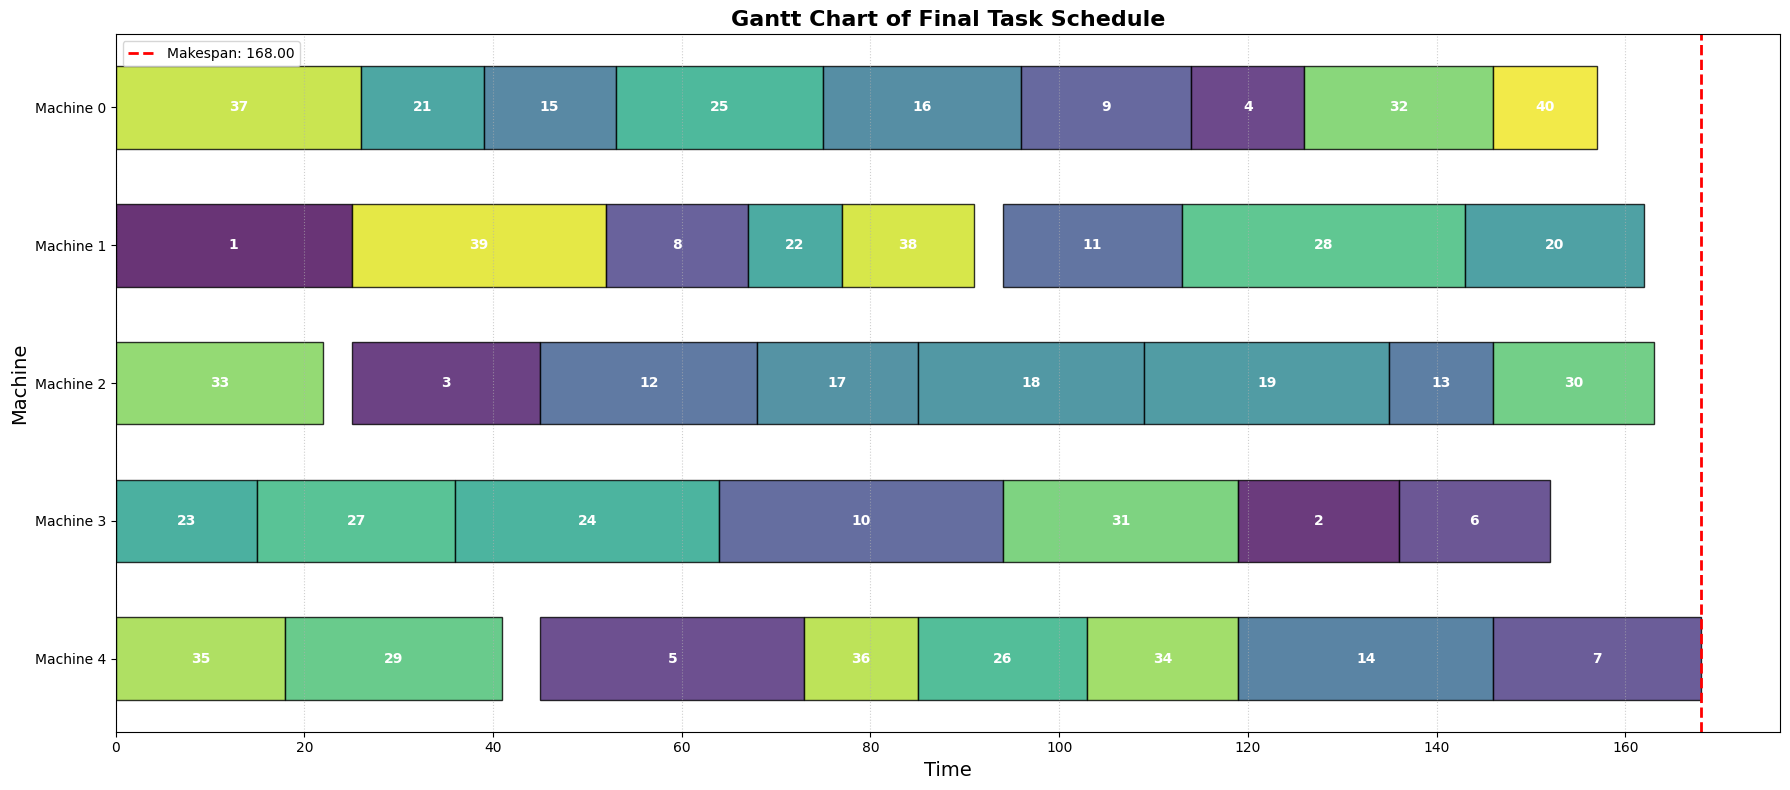

In [10]:
# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_history, color='purple')
plt.xlabel('Iteration')
plt.ylabel('Makespan')
plt.title('Evolution of Makespan with Precedence Constraints')
plt.grid(True, alpha=0.4)
plt.axhline(y=best_makespan, color='red', linestyle='--', label=f'Best: {best_makespan:.2f}')
plt.legend()
plt.show()

# --- Gantt Chart Visualization ---
def get_schedule_details(schedule, tasks, precedence):
    """
    Calculates start and end times for each task in a schedule.
    This is a detailed version of the makespan calculation.
    """
    completion_times = {task_id: 0 for task_id in tasks}
    machine_available_time = [0] * len(schedule)
    task_details = []
    
    scheduled_tasks = set()
    
    # Loop until all tasks have their details calculated
    while len(scheduled_tasks) < len(tasks):
        progress_made = False
        for machine_idx, machine_schedule in enumerate(schedule):
            for task_id in machine_schedule:
                if task_id in scheduled_tasks:
                    continue

                # Check if all predecessors are completed
                preds = precedence.get(task_id, [])
                if all(p in scheduled_tasks for p in preds):
                    
                    # Find the latest completion time among all predecessors
                    max_pred_completion_time = 0
                    if preds:
                        max_pred_completion_time = max(completion_times[p] for p in preds)
                    
                    # Task can only start when the machine is free AND all predecessors are done
                    start_time = max(machine_available_time[machine_idx], max_pred_completion_time)
                    duration = tasks[task_id]
                    end_time = start_time + duration
                    
                    # Store details
                    completion_times[task_id] = end_time
                    machine_available_time[machine_idx] = end_time
                    scheduled_tasks.add(task_id)
                    
                    task_details.append({
                        'task_id': task_id,
                        'machine': f'Machine {machine_idx}',
                        'start_time': start_time,
                        'end_time': end_time,
                        'duration': duration
                    })
                    progress_made = True
        
        if not progress_made:
            # This would indicate a cycle or invalid schedule
            break
            
    return task_details

# Get details from the best schedule found
schedule_details = get_schedule_details(best_schedule, tasks, precedence)

# Plotting the Gantt Chart
fig, ax = plt.subplots(figsize=(18, 8))

# Generate a color for each task
colors = plt.cm.viridis([i/num_tasks for i in range(num_tasks)])
task_colors = {i+1: colors[i] for i in range(num_tasks)}

for task in schedule_details:
    # Draw the bar for the task
    ax.barh(task['machine'], task['duration'], left=task['start_time'], height=0.6, 
            edgecolor='black', color=task_colors[task['task_id']], alpha=0.8)
    
    # Add the task ID inside the bar
    ax.text(task['start_time'] + task['duration']/2, task['machine'], f"{task['task_id']}", 
            ha='center', va='center', color='white', fontweight='bold')

# Formatting the chart
ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Machine', fontsize=14)
ax.set_title('Gantt Chart of Final Task Schedule', fontsize=16, fontweight='bold')

# Set y-axis to show all machines
ax.set_yticks(range(num_machines))
ax.set_yticklabels([f'Machine {i}' for i in range(num_machines)])
ax.invert_yaxis()  # To display Machine 0 at the top

# Add a vertical line for the makespan
ax.axvline(x=best_makespan, color='red', linestyle='--', linewidth=2, label=f'Makespan: {best_makespan:.2f}')
ax.legend()
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Conclusão

Esta terceira versão do problema de alocação de tarefas introduziu **restrições de precedência**, aumentando significativamente a complexidade e expondo os desafios de aplicar uma metaheurística como o Simulated Annealing a problemas altamente restritos.

### Complexidade da Implementação

A adaptação do SA para lidar com precedências não foi trivial e exigiu mudanças fundamentais:

1.  **Representação da Solução**: Tivemos que abandonar o simples dicionário `tarefa -> máquina` por um **cronograma explícito** (lista de listas), que define tanto a alocação quanto a ordem. Isso tornou a manipulação da solução mais complexa.

2.  **Função Objetivo (Makespan)**: O cálculo do makespan deixou de ser uma soma simples e se tornou uma **simulação completa do processo**, onde o tempo de início de cada tarefa depende tanto da disponibilidade da máquina quanto do tempo de término de suas predecessoras.

3.  **Geração de Vizinhos**: A maior dificuldade reside aqui. Movimentos aleatórios (como nos problemas anteriores) quase sempre geram soluções **inválidas**. A função `generate_neighbor` precisou ser "inteligente", garantindo que qualquer movimento (mover uma tarefa) resultasse em um cronograma que ainda respeitasse o grafo de precedência.

4.  **Validação Constante**: A cada passo, o algoritmo precisa garantir a validade da solução, o que adiciona uma sobrecarga computacional e de complexidade lógica.

### Análise do Desempenho do Simulated Annealing

-   **Eficácia**: O SA ainda consegue encontrar boas soluções, mas sua eficácia é mais sensível aos parâmetros (temperatura, taxa de resfriamento) e à qualidade da função de vizinhança. Um movimento mal projetado pode prender o algoritmo em regiões ruins do espaço de busca.

-   **Flexibilidade vs. Rigidez**: O SA é poderoso por sua capacidade de explorar o espaço de busca de forma flexível. No entanto, as restrições de precedência impõem uma rigidez que limita essa flexibilidade. O algoritmo precisa "desviar" de muitas soluções inválidas, tornando a busca menos eficiente.

-   **Custo Computacional**: A simulação necessária para calcular o makespan a cada iteração é muito mais custosa do que a simples soma das versões anteriores. Isso torna cada passo do algoritmo mais lento.

### Lições Aprendidas

1.  **SA não é uma "Bala de Prata"**: Embora poderoso, o SA precisa de adaptações significativas para problemas com restrições complexas. A "força bruta" da metaheurística precisa ser guiada por operadores de vizinhança que entendam as regras do problema.

2.  **A Representação é Chave**: A escolha da estrutura de dados para representar a solução é crucial.

3.  **Compromisso entre Simplicidade e Eficácia**: A função de vizinhança implementada (mover uma tarefa para uma posição válida) é relativamente simples. Operadores mais complexos (como trocar duas tarefas válidas) poderiam levar a uma exploração mais eficaz, mas com um custo ainda maior de implementação.

### Conclusão Final

Resolver o problema de scheduling com precedência usando Simulated Annealing é um excelente exercício que demonstra como uma metaheurística genérica pode ser adaptada para um domínio específico. Nos força a pensar profundamente sobre a representação da solução e a natureza do espaço de busca.

Embora o SA possa não ser a ferramenta mais especializada para este tipo de problema (algoritmos baseados em grafos ou programação por restrições poderiam ser mais diretos), ele se mostrou capaz de navegar por um espaço de busca complexo e encontrar soluções de alta qualidade, ao menos para o nosso caso de uso (Aula11_-_Problema_maquinas_paralelas_dificil.txt) que não é muito extenso.